<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

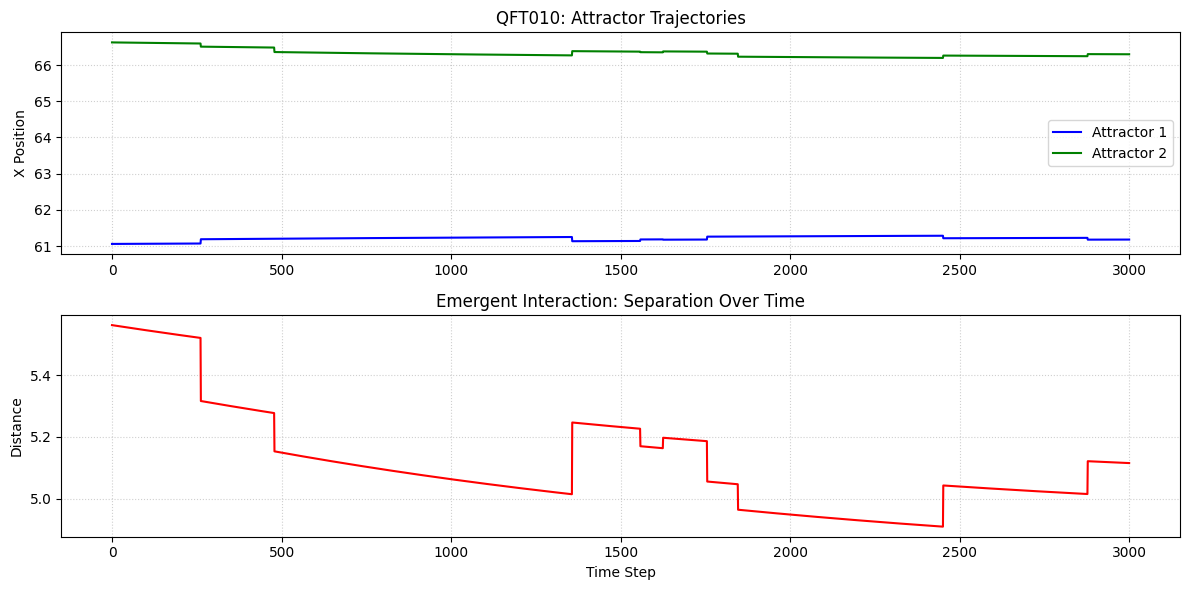

In [1]:
# QFT010: Two-Body Interaction Test — Colab Version
# Simulates two Gaussian attractors under HES PDE with fixed kappa = 0.1
# Tracks center-of-mass positions and separation over time

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# Parameters
N_grid = 128
T = 3000
dt = 0.01
delta = 0.10
gamma = 0.08
kappa = 0.1

# Initial positions
sep = 6
x = np.arange(N_grid)
y = np.arange(N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')

# Two Gaussian attractors
def gaussian(x0, y0, width=2.0, amp=0.01):
    return amp * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * width**2))

psi = gaussian(N_grid//2 - sep//2, N_grid//2) + gaussian(N_grid//2 + sep//2, N_grid//2)
psi = psi.astype(np.complex128)

# FFT kernel
kx = np.fft.fftfreq(N_grid) * (2 * np.pi)
ky = np.fft.fftfreq(N_grid) * (2 * np.pi)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)
implicit_denominator = 1 - dt * gamma * laplacian_kernel

# Trackers
com1_list = []
com2_list = []
sep_list = []

# Evolution loop
for t in range(T):
    # HES PDE
    restoring = -kappa * psi
    reaction = delta * np.abs(psi)**2 * psi
    rhs = psi + dt * (restoring + reaction)

    rhs_fft = np.fft.fft2(rhs)
    psi_new_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_new_fft)

    # Normalize for center-of-mass tracking
    psi_real = np.abs(psi)
    psi_thresh = psi_real > (0.5 * np.max(psi_real))

    # Label two regions
    labeled = np.zeros_like(psi_thresh, dtype=int)
    labeled[psi_thresh] = 1
    mid = N_grid // 2
    labeled[:mid, :] = labeled[:mid, :] * 1
    labeled[mid:, :] = labeled[mid:, :] * 2

    # Compute COMs
    mask1 = (labeled == 1)
    mask2 = (labeled == 2)
    com1 = center_of_mass(psi_real * mask1)
    com2 = center_of_mass(psi_real * mask2)

    com1_list.append(com1[0])
    com2_list.append(com2[0])
    sep_list.append(abs(com2[0] - com1[0]))

# Plotting
plt.figure(figsize=(12, 6))

# 1. Trajectories
plt.subplot(2, 1, 1)
plt.plot(com1_list, label='Attractor 1', color='blue')
plt.plot(com2_list, label='Attractor 2', color='green')
plt.title('QFT010: Attractor Trajectories')
plt.ylabel('X Position')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Separation
plt.subplot(2, 1, 2)
plt.plot(sep_list, label='Separation', color='red')
plt.title('Emergent Interaction: Separation Over Time')
plt.xlabel('Time Step')
plt.ylabel('Distance')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
